In [ ]:
!pip install scikit-learn pandas matplotlib seaborn --quiet

print("Libraries Installed!")

Libraries Installed!


In [ ]:
from google.colab import files

print("Upload your netflix_cleaned.csv file:")
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("netflix_cleaned.csv")

print(f"Loaded {len(df)} rows")
print(df.head(3))

Upload your netflix_cleaned.csv file:


Saving netflix_cleaned.csv to netflix_cleaned.csv
Loaded 8807 rows
  show_id     type                 title         director  \
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show         Blood & Water          Unknown   
2      s3  TV Show             Ganglands  Julien Leclercq   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   

   date_added  release_year rating   duration  ... tmdb_vote_avg  \
0  2021-09-25          2020  PG-13     90 min  ...         7.100   
1  2021-09-24          2021  TV-MA  2 Seasons  ...         7.800   
2  2021-09-24          2021  TV-MA   1 Season  ...         7.138   

  tmdb_vote_count  release_date  days_to_netflix  is_likely_original  \
0           140.0    2020-01-01            633.0          

# **MODEL 1 — CONTENT-BASED RECOMMENDER**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Building Content-Based Recommender...")

def make_soup(row):
  description = str(row["description"]) if pd.notna(row["description"]) else ""
  genres = str(row["listed_in"]).replace(","," ") if pd.notna(row["listed_in"]) else ""
  cast = str(row["cast"]) if pd.notna(row["cast"]) else ""

  cast_list = [c.strip().replace(" ","_") for c in cast.split(",")[:3]]
  cast_text = " ".join(cast_list)

  director = str(row["director"]).replace(" ","_") if pd.notna(row["director"]) else ""

  return f"{description} {genres} {cast_text} {director}"

df["soup"] = df.apply(make_soup, axis=1)

print("Sample soup for the first title:")
print(df["soup"].iloc[0][:200])

Building Content-Based Recommender...
Sample soup for the first title:
As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable. Documentaries Unknown Kirsten_Johnson


In [ ]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df["soup"])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print("(rows=titles, columns=unique words)")

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"\n Similarity matrix shape: {cosine_sim.shape}")
print("Model is ready!")

TF-IDF matrix shape: (8807, 5000)
(rows=titles, columns=unique words)

 Similarity matrix shape: (8807, 8807)
Model is ready!


In [ ]:
title_to_index = pd.Series(df.index, index=df["title"].str.lower()).drop_duplicates()

def recommend(title, num_recommendations=10):
  """
  Given a title, return the most similar titles.

  Example:
      recommend("Stranger Things")
      recommend("The Crown", num_recommendations=5)
  """

  title_lower = title.lower()

  if title_lower not in title_to_index:
    print(f"'{title}' not found in dataset.")
    print("Try  checking the spelling or use a title from Netflix")
    return None

  idx = title_to_index[title_lower]

  sim_scores = list(enumerate(cosine_sim[idx]))

  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

  sim_scores = sim_scores[1 : num_recommendations + 1]

  top_indices = [i[0] for i in sim_scores]
  top_scores = [round(i[1], 3) for i in sim_scores]

  results = df.iloc[top_indices][["title", "type", "listed_in", "release_year"]].copy()
  results["similarity_score"] = top_scores
  results = results.reset_index(drop=True)
  results.index += 1

  print(f"\n Because you watch: '{title}'")
  print(f"{'--' * 60}")
  print(f"Here are {num_recommendations} similar titles: \n")
  print(results.to_string())
  return results

In [ ]:
recommend("Stranger Things")


 Because you watch: 'Stranger Things'
------------------------------------------------------------------------------------------------------------------------
Here are 10 similar titles: 

                                    title     type                                                 listed_in  release_year  similarity_score
1                                  The OA  TV Show              TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy          2019             0.284
2                               Neo Yokio  TV Show           TV Comedies, TV Sci-Fi & Fantasy, Teen TV Shows          2018             0.269
3                                Manifest  TV Show              TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy          2021             0.267
4                           Hemlock Grove  TV Show                     TV Horror, TV Mysteries, TV Thrillers          2015             0.265
5                 The Autopsy of Jane Doe    Movie              Horror Movies, Independent Movies, Thrill

,title,type,listed_in,release_year,similarity_score
1,The OA,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",2019,0.284
2,Neo Yokio,TV Show,"TV Comedies, TV Sci-Fi & Fantasy, Teen TV Shows",2018,0.269
3,Manifest,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",2021,0.267
4,Hemlock Grove,TV Show,"TV Horror, TV Mysteries, TV Thrillers",2015,0.265
5,The Autopsy of Jane Doe,Movie,"Horror Movies, Independent Movies, Thrillers",2016,0.256
6,Star-Crossed,TV Show,"Romantic TV Shows, TV Dramas, TV Sci-Fi & Fantasy",2014,0.254
7,Sakho & Mangane,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",2019,0.254
8,Warrior Nun,TV Show,"TV Action & Adventure, TV Mysteries, TV Sci-Fi...",2020,0.253
9,Once Upon A Time In Lingjian Mountain,TV Show,"International TV Shows, TV Comedies, TV Sci-Fi...",2019,0.253
10,Anjaan: Special Crimes Unit,TV Show,"International TV Shows, TV Horror, TV Mysteries",2018,0.253


In [ ]:
recommend("The Crown")


 Because you watch: 'The Crown'
------------------------------------------------------------------------------------------------------------------------
Here are 10 similar titles: 

                                       title     type                                             listed_in  release_year  similarity_score
1             Stories by Rabindranath Tagore  TV Show                     International TV Shows, TV Dramas          2015             0.270
2   Elizabeth and Margaret: Love and Loyalty    Movie                                         Documentaries          2020             0.269
3                             The Last Czars  TV Show                                 Docuseries, TV Dramas          2019             0.254
4                              Downton Abbey  TV Show   British TV Shows, International TV Shows, TV Dramas          2015             0.248
5                              Ripper Street  TV Show           British TV Shows, Crime TV Shows, TV Dramas         

,title,type,listed_in,release_year,similarity_score
1,Stories by Rabindranath Tagore,TV Show,"International TV Shows, TV Dramas",2015,0.270
2,Elizabeth and Margaret: Love and Loyalty,Movie,Documentaries,2020,0.269
3,The Last Czars,TV Show,"Docuseries, TV Dramas",2019,0.254
4,Downton Abbey,TV Show,"British TV Shows, International TV Shows, TV D...",2015,0.248
5,Ripper Street,TV Show,"British TV Shows, Crime TV Shows, TV Dramas",2017,0.237
6,Greatest Events of WWII in Colour,TV Show,"British TV Shows, Docuseries, International TV...",2019,0.237
7,The Real Football Factories,TV Show,"British TV Shows, Docuseries, International TV...",2006,0.235
8,The A List,TV Show,"British TV Shows, International TV Shows, TV D...",2021,0.228
9,Dad's Army,TV Show,"British TV Shows, Classic & Cult TV, TV Comedies",1977,0.227
10,Age Gap Love,TV Show,"British TV Shows, Reality TV, Romantic TV Shows",2017,0.227



 Because you watch: 'Stranger Things'
------------------------------------------------------------------------------------------------------------------------
Here are 10 similar titles: 

                                    title     type                                                 listed_in  release_year  similarity_score
1                                  The OA  TV Show              TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy          2019             0.284
2                               Neo Yokio  TV Show           TV Comedies, TV Sci-Fi & Fantasy, Teen TV Shows          2018             0.269
3                                Manifest  TV Show              TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy          2021             0.267
4                           Hemlock Grove  TV Show                     TV Horror, TV Mysteries, TV Thrillers          2015             0.265
5                 The Autopsy of Jane Doe    Movie              Horror Movies, Independent Movies, Thrill

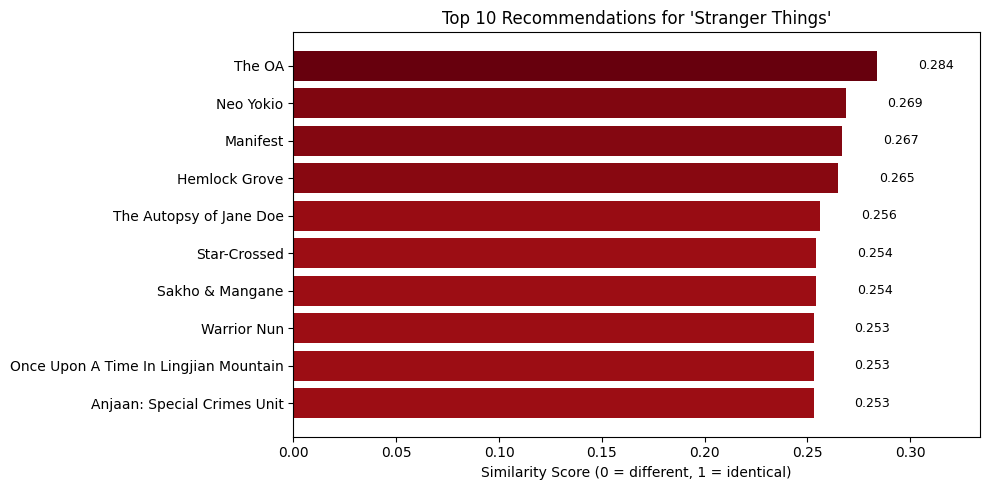

In [ ]:
def plot_recommendations(title, num_recommendations=10):
  results = recommend(title, num_recommendations)
  if results is None:
    return

  fig, ax = plt.subplots(figsize=(10,5))

  colors = plt.cm.Reds(
      [s / results["similarity_score"].max() for s in results["similarity_score"]]
  )

  bars = ax.barh(
      results["title"][::-1],
      results["similarity_score"][::-1],
      color=colors[::-1]
  )

  for bar, val in zip(bars, results["similarity_score"][::-1]):
      ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
              f"{val:.3f}", va="center", fontsize=9)

  ax.set_title(f"Top {num_recommendations} Recommendations for '{title}'")
  ax.set_xlabel("Similarity Score (0 = different, 1 = identical)")
  ax.set_xlim(0, results["similarity_score"].max() + 0.05)

  plt.tight_layout()
  plt.savefig("model1_recommendations.png", bbox_inches="tight")
  plt.show()

plot_recommendations("Stranger Things")

# **MODEL 2 — POPULARITY PREDICTOR**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

print("Preparing data for Popularity Predictor...")

model2_df = df[df["tmdb_popularity"].notna()].copy()
print(f"Rows with TMDB data: {len(model2_df)}")

features = [
    "type",
    "primary_genre",
    "primary_country",
    "rating",
    "cast_size",
    "genre_count",
    "release_year",
    "month_added",
    "duration_value"
]

target = "tmdb_popularity"

model2_df = model2_df[features + [target]].dropna()

print(f"Rows after dropping nulls: {len(model2_df)}")

label_encoders = {}
text_columns = ["type","primary_genre","primary_country","rating"]

for col in text_columns:
  le = LabelEncoder()
  model2_df[col] = le.fit_transform(model2_df[col].astype(str))
  label_encoders[col] = le

print("\n Data Prepared!")
print(model2_df.head())

Preparing data for Popularity Predictor...
Rows with TMDB data: 95
Rows after dropping nulls: 95

 Data Prepared!
   type  primary_genre  primary_country  rating  cast_size  genre_count  \
0     0              6               14       1          0            1   
1     1             11               10       5         19            3   
2     1              5               15       5          9            3   
3     1              7               15       5          0            2   
4     1             11                6       5          8            3   

   release_year  month_added  duration_value  tmdb_popularity  
0          2020          9.0            90.0           0.8701  
1          2021          9.0             2.0           6.4325  
2          2021          9.0             1.0           3.4822  
3          2021          9.0             1.0           0.0791  
4          2021          9.0             2.0           5.8611  


In [ ]:
X = model2_df[features]
y = model2_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(y_test)}")

model2 = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)

print("\nTraining Random Forest...(may take 30 seconds)")
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n Model Trained")
print(f"Mean Abolute Error is: {mae:.2f}")
print(f"On average, predictions are off by {mae:.2f} popularity points")
print(f"R^2 Score: {r2:.3f}")
print(f"The model explains {r2*100:.1f}% of the variation in popularity")

Training rows: 76
Testing rows: 19

Training Random Forest...(may take 30 seconds)

 Model Trained
Mean Abolute Error is: 9.88
On average, predictions are off by 9.88 popularity points
R^2 Score: 0.188
The model explains 18.8% of the variation in popularity


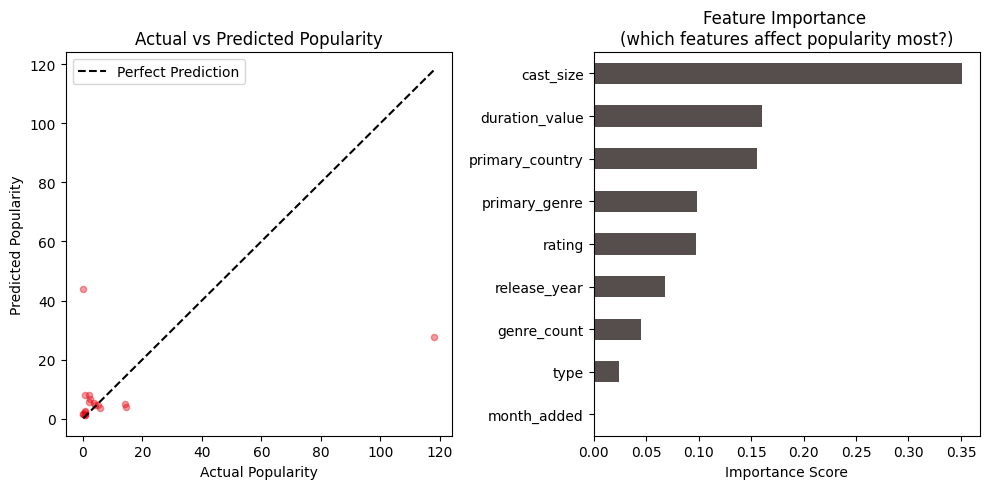

Insight: See which features the model relies on most.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].scatter(y_test, y_pred, alpha=0.4, color="#E50914", s=20)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "k--", linewidth=1.5, label="Perfect Prediction"
)

axes[0].set_xlabel("Actual Popularity")
axes[0].set_ylabel("Predicted Popularity")
axes[0].set_title("Actual vs Predicted Popularity")
axes[0].legend()

importances = pd.Series(
    model2.feature_importances_,
    index = features
).sort_values(ascending=True)

importances.plot(kind="barh", ax=axes[1], color="#564d4d")
axes[1].set_title("Feature Importance \n(which features affect popularity most?)")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("model2_popularity_predictor.png", bbox_inches="tight")
plt.show()

print("Insight: See which features the model relies on most.")

In [ ]:
def predict_popularity(content_type, genre, country, rating, cast_size, genre_count, release_year, month_added, duration):
  """
  Predict the TMDB popularity score for a hypothetical new Title.
  """

  def encode(col, value):
      le = label_encoders[col]
      if value in le.classes_:
          return le.transform([value])[0]
      else:
          print(f"Note: '{value}' not seen during training - using closest match")
          return 0
  input_data = pd.DataFrame([{
      "type": encode("type", content_type),
      "primary_genre": encode("primary_genre", genre),
      "primary_country": encode("primary_country", country),
      "rating": encode("rating", rating),
      "cast_size": cast_size,
      "genre_count": genre_count,
      "release_year": release_year,
      "month_added": month_added,
      "duration_value": duration
  }])

  predicted = model2.predict(input_data)[0]
  print(f"\n Predicted TMDB Popularity Score: {predicted:.2f}")
  print(f"(Average on Netflix is ~{y.mean():.2f})")
  if predicted > y.mean():
    print("Above Average - this could be a hit")
  else:
    print("Below Average - may need a stronger cast or concept.")
  return predicted

predict_popularity(
    content_type = "Movie",
    genre = "Dramas",
    country = "India",
    rating = "TV-MA",
    cast_size = 5,
    genre_count = 2,
    release_year = 2024,
    month_added = 10,
    duration = 120
)


 Predicted TMDB Popularity Score: 1.29
(Average on Netflix is ~6.32)
Below Average - may need a stronger cast or concept.


np.float64(1.2925849999999994)

#**MODEL 3 — GENRE CLASSIFIER (NLP)**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer as TF
from sklearn.metrics import classification_report, confusion_matrix

print("Preparing data for Genre Classifier...")

model3_df = df[df["description"].notna() & df["primary_genre"].notna()].copy()

top_genres = model3_df["primary_genre"].value_counts().head(8).index.tolist()
model3_df = model3_df[model3_df["primary_genre"].isin(top_genres)]

print(f"Rows for training: {len(model3_df)}")
print(f"Genres we're classifying: {top_genres}")

X_text = model3_df["description"]
y_genre = model3_df["primary_genre"]

Preparing data for Genre Classifier...
Rows for training: 6664
Genres we're classifying: ['Dramas', 'Comedies', 'Action & Adventure', 'Documentaries', 'International TV Shows', 'Children & Family Movies', 'Crime TV Shows', "Kids' TV"]


In [ ]:
X_train_t, X_test_t, y_train_g, y_test_g = train_test_split(
    X_text, y_genre, test_size=0.2, random_state=42, stratify=y_genre
)

tfidf3 = TF(
    stop_words = "english",
    max_features = 3000,
    ngram_range = (1, 2)
)

X_train_tfidf = tfidf3.fit_transform(X_train_t)
X_test_tfidf = tfidf3.transform(X_test_t)

model3 = LogisticRegression(
    max_iter = 1000,
    random_state = 42,
    C = 1.0
)

print("Training Genre Classifier...")
model3.fit(X_train_tfidf, y_train_g)

y_pred_genre = model3.predict(X_test_tfidf)
accuracy = (y_pred_genre == y_test_g).mean()

print(f"Model Trained!")
print(f"Accuracy: {accuracy *100:.1f}%")
print(f"The model correctly predicts the genre {accuracy*100:.1f}% of the time")
print("\nDetailed Report:")
print(classification_report(y_test_g, y_pred_genre))

Training Genre Classifier...
Model Trained!
Accuracy: 50.3%
The model correctly predicts the genre 50.3% of the time

Detailed Report:
                          precision    recall  f1-score   support

      Action & Adventure       0.52      0.47      0.49       172
Children & Family Movies       0.54      0.43      0.48       121
                Comedies       0.43      0.49      0.46       242
          Crime TV Shows       0.58      0.23      0.32        80
           Documentaries       0.79      0.67      0.73       166
                  Dramas       0.43      0.72      0.54       320
  International TV Shows       0.39      0.19      0.25       155
                Kids' TV       0.89      0.42      0.57        77

                accuracy                           0.50      1333
               macro avg       0.57      0.45      0.48      1333
            weighted avg       0.53      0.50      0.49      1333



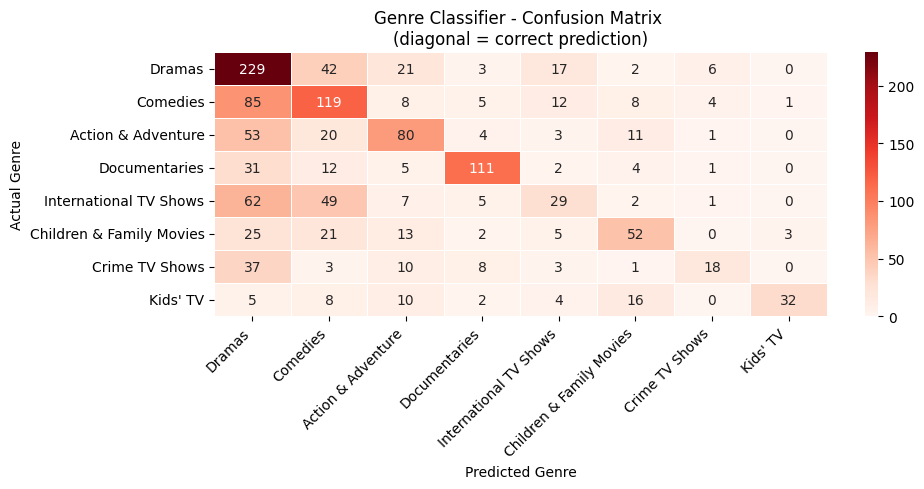

In [ ]:
cm = confusion_matrix(y_test_g, y_pred_genre, labels=top_genres)
cm_df = pd.DataFrame(cm, index=top_genres, columns=top_genres)

fig, ax = plt.subplots(figsize=(10,5))

sns.heatmap(
    cm_df,
    annot = True,
    fmt = "d",
    cmap = "Reds",
    ax = ax,
    linewidth = 0.5
)

ax.set_title("Genre Classifier - Confusion Matrix \n(diagonal = correct prediction)")
ax.set_ylabel("Actual Genre")
ax.set_xlabel("Predicted Genre")
plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("model3_confusion_matrix.png", bbox_inches="tight")
plt.show()

In [ ]:
def predict_genre(description_text):
  """
    Given a description, predict what genre it belongs to.

    Example:
        predict_genre("A group of friends investigate supernatural events in a small town.")
        predict_genre("A stand-up comedian reflects on his life and career.")
  """

  text_tfidf = tfidf3.transform([description_text])
  predicted = model3.predict(text_tfidf)[0]

  proba = model3.predict_proba(text_tfidf)[0]
  confidence_df = pd.DataFrame({
      "genre": model3.classes_,
      "confidence": [round(p * 100, 1) for p in proba]
  }).sort_values("confidence", ascending=False)

  print(f"\n Description '{description_text[:80]}'...")
  print(f"\n Predicted Genre: {predicted}")
  print(f"\nConfidence score")
  print(confidence_df.to_string(index=False))
  return predicted


predict_genre(
    "A group of teenagers discover they have supernatural powers"
    "and must use them to fight an ancient evil threatning their town"
)


 Description 'A group of teenagers discover they have supernatural powersand must use them to '...

 Predicted Genre: Action & Adventure

Confidence score
                   genre  confidence
      Action & Adventure        30.9
                Kids' TV        28.8
  International TV Shows        11.0
Children & Family Movies         7.2
                Comedies         6.4
          Crime TV Shows         5.3
                  Dramas         5.2
           Documentaries         5.1


'Action & Adventure'

In [ ]:
my_description = "A famous chef travels the world learning new recipes and cultures."

predict_genre(my_description)


 Description 'A famous chef travels the world learning new recipes and cultures.'...

 Predicted Genre: Kids' TV

Confidence score
                   genre  confidence
                Kids' TV        19.5
  International TV Shows        18.6
                Comedies        15.1
                  Dramas        15.0
           Documentaries        13.3
Children & Family Movies         9.2
      Action & Adventure         6.0
          Crime TV Shows         3.4


"Kids' TV"

In [ ]:
print("=" * 60)
print("ML MODELS — COMPLETE SUMMARY")
print("=" * 60)

print("\n MODEL 1: Content-Based Recommender")
print("   Method:  TF-IDF + Cosine Similarity")
print("   Input:   A Netflix title name")
print("   Output:  10 most similar titles")
print("   Use:     Powers a recommendation engine")

print("\n MODEL 2: Popularity Predictor")
print("   Method:  Random Forest Regression")
print(f"   MAE:     {mae:.2f} | R²: {r2:.3f}")
print("   Input:   Genre, country, rating, cast size, etc.")
print("   Output:  Predicted TMDB popularity score")
print("   Use:     Helps decide which content to commission")

print("\n MODEL 3: Genre Classifier")
print("   Method:  TF-IDF + Logistic Regression (NLP)")
print(f"   Accuracy:{accuracy*100:.1f}%")
print("   Input:   A show/movie description (text)")
print("   Output:  Predicted genre")
print("   Use:     Auto-tag new content at scale")

print("\n✓ All 3 models complete!")
print("✓ Charts saved as PNG files")
print("\nNext step: Tableau Dashboards! ")

ML MODELS — COMPLETE SUMMARY

 MODEL 1: Content-Based Recommender
   Method:  TF-IDF + Cosine Similarity
   Input:   A Netflix title name
   Output:  10 most similar titles
   Use:     Powers a recommendation engine

 MODEL 2: Popularity Predictor
   Method:  Random Forest Regression
   MAE:     9.88 | R²: 0.188
   Input:   Genre, country, rating, cast size, etc.
   Output:  Predicted TMDB popularity score
   Use:     Helps decide which content to commission

 MODEL 3: Genre Classifier
   Method:  TF-IDF + Logistic Regression (NLP)
   Accuracy:50.3%
   Input:   A show/movie description (text)
   Output:  Predicted genre
   Use:     Auto-tag new content at scale

✓ All 3 models complete!
✓ Charts saved as PNG files

Next step: Tableau Dashboards! 
